In [6]:
# Part A (1)

!pip install nltk
import pandas as pd 
%matplotlib inline
import matplotlib.pyplot as plt 
from nltk.corpus import stopwords
from collections import Counter
from textblob import TextBlob
import re
import seaborn as sns

df = pd.read_csv('tweets_disney_5000.csv')

df.head(5)

import nltk 
nltk.download('stopwords')

# Tokenization
def popular_words(text, remove_stopwords=True):
    words = re.findall(r'\b\w+\b', text.lower())

    if remove_stopwords:
        stop_words = set(stopwords.words('english'))
        words = [word for word in words if word not in stop_words]

# Counting the occurences 
    word_counts = Counter(words)

    most_common_words = word_counts.most_common(10)

    return most_common_words

# Making all tweets into a single text
all_tweets_text = ' '.join(df['tweet_text'])


# Finding words with and without stop words
popular_words_with_stopwords = popular_words(all_tweets_text, remove_stopwords=False)
popular_words_without_stopwords = popular_words(all_tweets_text, remove_stopwords=True)

print("Top 10 popular words with stopwords:", popular_words_with_stopwords)
print("\nTop 10 popular words without stopwords:", popular_words_without_stopwords)


Top 10 popular words with stopwords: [('disney', 3865), ('the', 3634), ('rt', 3137), ('t', 1962), ('in', 1910), ('a', 1801), ('https', 1746), ('to', 1636), ('co', 1631), ('is', 1606)]

Top 10 popular words without stopwords: [('disney', 3865), ('rt', 3137), ('https', 1746), ('co', 1631), ('wandavision', 559), ('kathryn', 553), ('agatha', 530), ('hahn', 513), ('spinoff', 406), ('racist', 403)]


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/aanandiyadav/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [7]:
#Part A (2)

# Extracting hashtagss from text
def pop_hashtags(text):
    hashtags = re.findall(r'#\w+', text.lower())
    return hashtags

# Extracting hashtags from tweets
all_hashtags = [tag for tweet in df['tweet_text'] for tag in pop_hashtags(tweet)]

# Counting occurances 
hashtag_counts = Counter(all_hashtags)

popular_hashtags = hashtag_counts.most_common(10)

print("Top 10 popular hashtags:", popular_hashtags)

Top 10 popular hashtags: [('#wandavision', 225), ('#disney', 222), ('#disneyplus', 85), ('#theowlhouse', 71), ('#sweepstakes', 64), ('#disneyworld50', 44), ('#taekookau', 43), ('#belfra', 43), ('#enhypen', 43), ('#dancegodjimin', 43)]


In [11]:
# Part A (3)

file_path = 'tweets_disney_5000.csv'
df = pd.read_csv(file_path)

def extract_usernames(tweet):
    usernames = re.findall(r'@\w+', tweet)
    return usernames

df['usernames'] = df['tweet_text'].apply(extract_usernames)


allusernames = [item for sublist in df['usernames'].dropna() for item in sublist]

counts_username = Counter(allusernames)

topusernames = counts_username.most_common(10)

print("10 Most Frequently Mentioned Usernames:")
for username, count in topusernames:
    print(f"{username}: {count}")

10 Most Frequently Mentioned Usernames:
@Parkour_Lewis: 390
@Variety: 270
@Disney: 200
@DiscussingFilm: 163
@Adam_Cesare: 116
@DisneyAPromos: 101
@rapsandcass: 87
@LeCinephiles: 64
@StopTweetingMia: 58
@So_Ethereal: 56


In [12]:
# Part A (4)

file_path = 'tweets_disney_5000.csv'
df = pd.read_csv(file_path)

usercounts = df['user_screen_name'].value_counts()

mostfrequentuser = usercounts.idxmax()
frequency_of_mostfrequentuser = usercounts.max()

print(f"The most frequent tweeting person (user) is: {mostfrequentuser} with {frequency_of_mostfrequentuser} tweets.")


The most frequent tweeting person (user) is: gemmacoIlins with 40 tweets.


In [13]:
# Part A (5)

df = pd.read_csv('tweets_disney_5000.csv')

retweets_df = df[df['is_retweet'] == True]

retweets_df['user_influence'] = retweets_df['source_user_followers_count'] + retweets_df['source_user_friends_count'] + retweets_df['source_user_listed_count'] + retweets_df['source_user_favourites_count'] 

most_influential_user_retweets = retweets_df.loc[retweets_df['user_influence'].idxmax()]

print("Most Influential User Among Retweets")
print("User:", most_influential_user_retweets['source_user_name'])
print("Influence Score:", most_influential_user_retweets['user_influence'])

print("\n")

# Part B (6)

retweets_df['retweet_influence'] = retweets_df['source_tweet_quote_count'] + retweets_df['source_tweet_reply_count'] + retweets_df['source_tweet_retweet_count'] + retweets_df['source_tweet_favorite_count']

most_influential_retweet = retweets_df.loc[retweets_df['retweet_influence'].idxmax()]

print("Most Influential Retweet")
print("Tweet:", most_influential_retweet['source_tweet_text'])
print("Influence Score:", most_influential_retweet['retweet_influence'])     

Most Influential User Among Retweets
User: Christina Aguilera
Influence Score: 16712234.0


Most Influential Retweet
Tweet: #Rapunzel
#DisneyPrincess 

Try to imitate Disney Princess https://t.co/ReaZV5ApiX
Influence Score: 160746.0


/tmp/ipykernel_94432/1004850908.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  retweets_df['user_influence'] = retweets_df['source_user_followers_count'] + retweets_df['source_user_friends_count'] + retweets_df['source_user_listed_count'] + retweets_df['source_user_favourites_count']
/tmp/ipykernel_94432/1004850908.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  retweets_df['retweet_influence'] = retweets_df['source_tweet_quote_count'] + retweets_df['source_tweet_reply_count'] + retweets_df['sourc

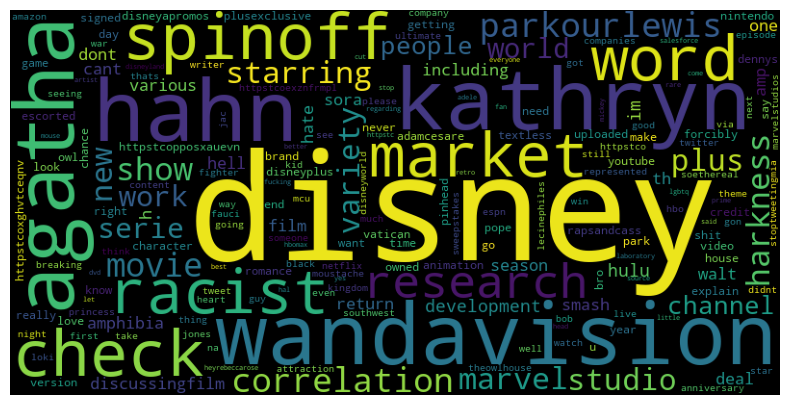

<Figure size 640x480 with 0 Axes>

In [14]:
# Part B

from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize

#open file
import pandas as pd
df=pd.read_csv('tweets_disney_5000.csv')
df.head()


#get the text of tweets
text_n = df.loc[:,'tweet_text']
text=''
for t in text_n:
    text += str(t)+' '
text


df['tweet_text'].head(2)


#remove puncs & dgts
import string
puncs = string.punctuation
dgts = string.digits
table = str.maketrans('','',dgts+puncs)
text_less_clean = text.translate(table)
text_less_clean = ' '.join(text_less_clean.split())
text_less_clean

#remove stop words
stopwords = nltk.corpus.stopwords.words('english')
stopwords=stopwords+['gets','rt','vs']
text_clean = ''
for word in word_tokenize(text_less_clean.lower()):
    if word in stopwords:
        continue
    text_clean = text_clean + ' ' + word
text_clean


#generate the wordcloud
wordcloud2 = WordCloud(width=800, height=400,collocations=False).generate(text_clean)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud2)
plt.axis('off')
plt.show()
plt.savefig('wordcloud.png') 

In [16]:
# Part C 

# install textblob
get_ipython().system('pip install textblob')
from textblob import TextBlob

#open file
import pandas as pd
df=pd.read_csv('tweets_disney_5000.csv')
df.head()

pol=[]
sub=[]
for tweets in tweet_list:
    sentiments=TextBlob(tweets).sentiment
    pol.append(sentiments.polarity)
    sub.append(sentiments.subjectivity)
pol_average=round(sum(pol)/5000,5)
sub_average=round(sum(sub)/5000,5)
print('The average polarity and subjectivity scores={},{}'.format(pol_average,sub_average))

The average polarity and subjectivity scores=0.06672,0.37303


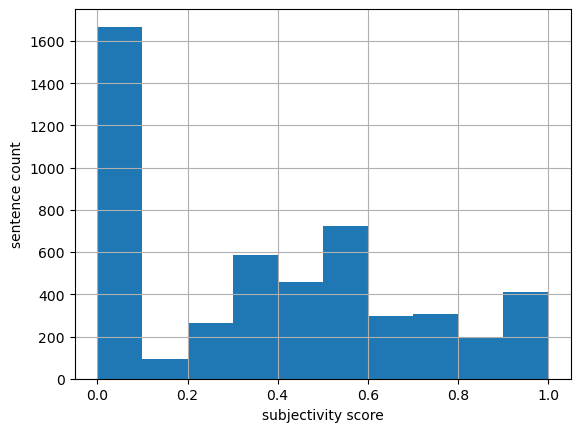

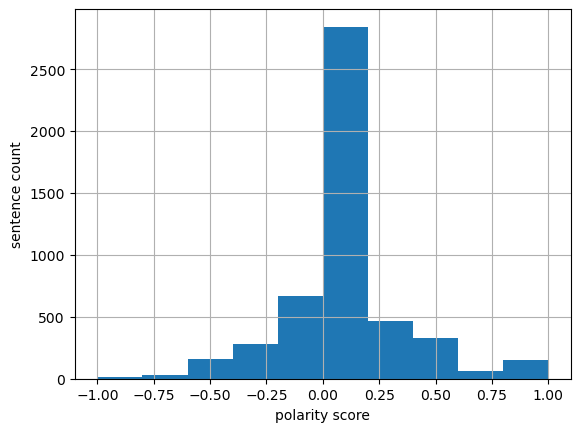

In [17]:
#visualize the sentiment scores
import matplotlib.pyplot as plt
plt.hist(sub, bins=10)
plt.xlabel('subjectivity score')
plt.ylabel('sentence count')
plt.grid(True)
plt.savefig('subjectivity.png')
plt.show()


plt.hist(pol, bins=10)
plt.xlabel('polarity score')
plt.ylabel('sentence count')
plt.grid(True)
plt.savefig('polarity.png')
plt.show()

In [18]:
positive=-1
negative=1
most_positive=[]
most_negative=''
for tweets in tweet_list:
    sentiments=TextBlob(tweets).sentiment
    p_t=sentiments.polarity
    if p_t>positive:
        positive=p_t
        most_positive=tweets
    if p_t<negative:
        negative=p_t
        most_negative=tweets
print(positive,most_positive)
print(negative,most_negative)

1.0 RT @MnCloud9: @brydisanto @NoKapRich @NFHeroes is one of the best opportunities in NFT if ya miss out on Meka!  The artists worked at Disne
-1.0 Disney is evil.


In [19]:
for tweets in tweet_list:
    sentiments=TextBlob(tweets).sentiment
    p_t=sentiments.polarity
    if p_t==1:
        print('positive   '+tweets)
    if p_t==-1:
        print('negative   '+tweets)

positive   RT @MnCloud9: @brydisanto @NoKapRich @NFHeroes is one of the best opportunities in NFT if ya miss out on Meka!  The artists worked at Disne
positive   RT @MamasGeeky: Kathryn Hahn as Agatha Harkness is one if my favorite things in this world and a spinoff?!?! Yes please!!!!
positive   The 50th anniversary celebration is here! Enter using #Sweepstakes for a chance to win a 4-night vacation package for you and 3 guests to the Walt Disney World Resort from Southwest! NO PURCH NEC. Rules: bitly.url/1234. #Sweepstakes #Southwest50 #DisneyWorld50
positive   The 50th anniversary celebration is here! Enter using #Sweepstakes for a chance to win a 4-night vacation package for you and 3 guests to the Walt Disney World Resort from Southwest! NO PURCH NEC. Rules: bitly.url/1234. #Sweepstakes #Southwest50 #DisneyWorld50
positive   The 50th anniversary celebration is here! Enter using #Sweepstakes for a chance to win a 4-night vacation package for you and 3 guests to the Walt Disney World